## Extraemos el dataset CASME II

In [1]:
from zipfile import ZipFile

In [ ]:
zip = ZipFile("CASME-II-Binary-splitted.zip")
zip.extractall()
zip.close()

## Inspeccionamos el dataset

In [2]:
import os

data_dir = "CASME-II-Binary-splitted"

for dir, dirname, files in os.walk(data_dir):
    print(f"Dir: {dir} | subdir: {dirname} | cant de imagenes: {len(files)} ")

Dir: CASME-II-Binary-splitted | subdir: ['test', 'train', 'val'] | cant de imagenes: 0 
Dir: CASME-II-Binary-splitted\test | subdir: ['ME', 'NE'] | cant de imagenes: 0 
Dir: CASME-II-Binary-splitted\test\ME | subdir: [] | cant de imagenes: 1617 
Dir: CASME-II-Binary-splitted\test\NE | subdir: [] | cant de imagenes: 1617 
Dir: CASME-II-Binary-splitted\train | subdir: ['ME', 'NE'] | cant de imagenes: 0 
Dir: CASME-II-Binary-splitted\train\ME | subdir: [] | cant de imagenes: 12927 
Dir: CASME-II-Binary-splitted\train\NE | subdir: [] | cant de imagenes: 12927 
Dir: CASME-II-Binary-splitted\val | subdir: ['ME', 'NE'] | cant de imagenes: 0 
Dir: CASME-II-Binary-splitted\val\ME | subdir: [] | cant de imagenes: 1615 
Dir: CASME-II-Binary-splitted\val\NE | subdir: [] | cant de imagenes: 1615 


## Preparamos los datos con TensorFlow

In [3]:
import tensorflow as tf

tf.random.set_seed(42)

img_size = (224, 224)
batch_size = 4
epochs = 500

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(f"{data_dir}/train",
                                                    target_size=img_size,
                                                    batch_size=batch_size,
                                                    class_mode='binary',
                                                    shuffle=True)

test_generator = datagen.flow_from_directory(f"{data_dir}/test",
                                                target_size=img_size,
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=False)

val_generator = datagen.flow_from_directory(f"{data_dir}/val",
                                                target_size=img_size,
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=False)

Found 25854 images belonging to 2 classes.
Found 3234 images belonging to 2 classes.
Found 3230 images belonging to 2 classes.


In [4]:
imagenes, labels = train_generator[0]
print(imagenes.shape)
print(labels.shape)

(4, 224, 224, 3)
(4,)


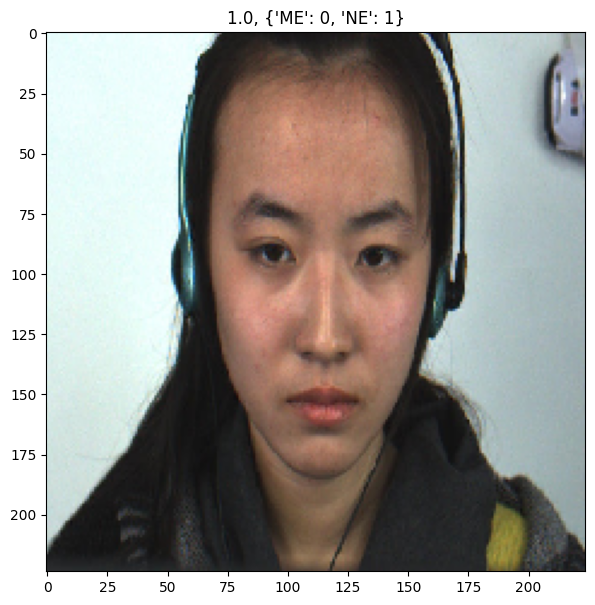

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.imshow(imagenes[0])
plt.title(f"{labels[0]}, {train_generator.class_indices}")
plt.show()

In [6]:
clases = train_generator.class_indices
print(clases)

{'ME': 0, 'NE': 1}


## Implementamos una arquitectura CNN

In [6]:
base_model = tf.keras.applications.ResNet50V2(
    weights='imagenet',
    include_top=False)

base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    # loss=tf.keras.losses.CategoricalCrossentropy(),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'model_me_ne.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, None, None,     │    23,564,800 │
│                                 │ 2048)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,089,601 (91.89 MB)

 Trainable params: 524,801 (2.00 MB)

...

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3206s 496ms/step - accuracy: 0.8712 - loss: 0.2736 - precision: 0.9241 - recall: 0.8089 - val_accuracy: 0.8802 - val_loss: 0.2853 - val_precision: 0.9456 - val_recall: 0.8068
Epoch 101/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8656 - loss: 0.2776 - precision: 0.9181 - recall: 0.7996
Epoch 101: val_accuracy did not improve from 0.88019
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3241s 501ms/step - accuracy: 0.8695 - loss: 0.2735 - precision: 0.9196 - recall: 0.8098 - val_accuracy: 0.8647 - val_loss: 0.3059 - val_precision: 0.9250 - val_recall: 0.7938
Epoch 102/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8720 - loss: 0.2747 - precision: 0.9227 - recall: 0.8115
Epoch 102: val_accuracy did not improve from 0.88019
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3278s 507ms/step - accuracy: 0.8727 - loss: 0.2753 - precision: 0.9252 - recall: 0.8109 - val_accuracy: 0.8533 - val_loss: 0.3294 - val_precision: 0.8586 - val_recall: 0.8458
Epoch 103/500
64

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3544s 548ms/step - accuracy: 0.8721 - loss: 0.2702 - precision: 0.9222 - recall: 0.8127 - val_accuracy: 0.8811 - val_loss: 0.2890 - val_precision: 0.9387 - val_recall: 0.8155
Epoch 107/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.8711 - loss: 0.2730 - precision: 0.9244 - recall: 0.8071
Epoch 107: val_accuracy did not improve from 0.88111
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3606s 558ms/step - accuracy: 0.8722 - loss: 0.2716 - precision: 0.9236 - recall: 0.8115 - val_accuracy: 0.8746 - val_loss: 0.3109 - val_precision: 0.9231 - val_recall: 0.8173
Epoch 108/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8734 - loss: 0.2649 - precision: 0.9230 - recall: 0.8155
Epoch 108: val_accuracy did not improve from 0.88111
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 3739s 578ms/step - accuracy: 0.8713 - loss: 0.2695 - precision: 0.9228 - recall: 0.8104 - val_accuracy: 0.8728 - val_loss: 0.3043 - val_precision: 0.9493 - val_recall: 0.7876
Epoch 109/500
64

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 4772s 738ms/step - accuracy: 0.8773 - loss: 0.2633 - precision: 0.9284 - recall: 0.8177 - val_accuracy: 0.8842 - val_loss: 0.2738 - val_precision: 0.9487 - val_recall: 0.8124
Epoch 121/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.8808 - loss: 0.2604 - precision: 0.9325 - recall: 0.8215
Epoch 121: val_accuracy did not improve from 0.88421
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 4813s 745ms/step - accuracy: 0.8770 - loss: 0.2641 - precision: 0.9274 - recall: 0.8180 - val_accuracy: 0.8752 - val_loss: 0.2797 - val_precision: 0.9372 - val_recall: 0.8043
Epoch 122/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.8765 - loss: 0.2614 - precision: 0.9275 - recall: 0.8173
Epoch 122: val_accuracy did not improve from 0.88421
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 4902s 758ms/step - accuracy: 0.8780 - loss: 0.2624 - precision: 0.9276 - recall: 0.8201 - val_accuracy: 0.8777 - val_loss: 0.2820 - val_precision: 0.9127 - val_recall: 0.8353
Epoch 123/500
64

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 5086s 787ms/step - accuracy: 0.8796 - loss: 0.2583 - precision: 0.9283 - recall: 0.8227 - val_accuracy: 0.8854 - val_loss: 0.2646 - val_precision: 0.9261 - val_recall: 0.8378
Epoch 125/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.8850 - loss: 0.2506 - precision: 0.9344 - recall: 0.8284
Epoch 125: val_accuracy did not improve from 0.88545
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 5136s 794ms/step - accuracy: 0.8813 - loss: 0.2540 - precision: 0.9299 - recall: 0.8246 - val_accuracy: 0.8734 - val_loss: 0.2865 - val_precision: 0.9199 - val_recall: 0.8180
Epoch 126/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.8763 - loss: 0.2589 - precision: 0.9288 - recall: 0.8153
Epoch 126: val_accuracy did not improve from 0.88545
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 5224s 808ms/step - accuracy: 0.8779 - loss: 0.2592 - precision: 0.9300 - recall: 0.8172 - val_accuracy: 0.8796 - val_loss: 0.2785 - val_precision: 0.9092 - val_recall: 0.8433
Epoch 127/500
64

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 6684s 1s/step - accuracy: 0.8854 - loss: 0.2509 - precision: 0.9355 - recall: 0.8279 - val_accuracy: 0.8864 - val_loss: 0.2664 - val_precision: 0.9100 - val_recall: 0.8576
Epoch 138/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.8833 - loss: 0.2488 - precision: 0.9319 - recall: 0.8278
Epoch 138: val_accuracy did not improve from 0.88638
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 6621s 1s/step - accuracy: 0.8814 - loss: 0.2524 - precision: 0.9309 - recall: 0.8241 - val_accuracy: 0.8777 - val_loss: 0.2880 - val_precision: 0.9363 - val_recall: 0.8105
Epoch 139/500
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.8801 - loss: 0.2578 - precision: 0.9327 - recall: 0.8199
Epoch 139: val_accuracy did not improve from 0.88638
6464/6464 ━━━━━━━━━━━━━━━━━━━━ 6756s 1s/step - accuracy: 0.8830 - loss: 0.2540 - precision: 0.9341 - recall: 0.8242 - val_accuracy: 0.8700 - val_loss: 0.3000 - val_precision: 0.8751 - val_recall: 0.8632
Epoch 140/500
6464/6464 ━

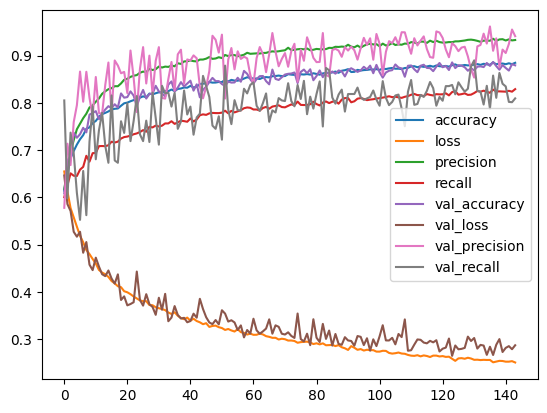

In [7]:
import pandas as pd

pd.DataFrame(history.history).plot()
plt.show()

In [8]:
model.evaluate(val_generator, verbose=1)

808/808 ━━━━━━━━━━━━━━━━━━━━ 857s 1s/step - accuracy: 0.8854 - loss: 0.2646 - precision: 0.9261 - recall: 0.8378


[0.26456907391548157,
 0.8854489326477051,
 0.9260780215263367,
 0.8377708792686462]

In [9]:
from sklearn import metrics as ms
import numpy as np
import seaborn as sns

val_loss, val_acc, val_precision, val_recall = model.evaluate(val_generator, verbose=1)

predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print(ms.classification_report(y_true, y_pred, target_names=clases))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(history.history['loss'], label='Entrenamiento')
axes[0, 0].plot(history.history['val_loss'], label='Validación')
axes[0, 0].set_title('Pérdida del Modelo')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 1].plot(history.history['accuracy'], label='Entrenamiento')
axes[0, 1].plot(history.history['val_accuracy'], label='Validación')
axes[0, 1].set_title('Precisión del Modelo')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Precisión')
axes[0, 1].legend()
axes[0, 1].grid(True)
plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

cm = ms.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=clases,
           yticklabels=clases)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# model.save('casme_2_binary_model.h5')
print('¡Entrenamiento completado!')


ModuleNotFoundError: No module named 'sklearn'

## Segunda prueba sin Data Augmentation

In [ ]:
tf.random.set_seed(42)

img_size = (224, 224)
batch_size = 32
epochs = 100

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(f"{data_dir}/train",
                                                target_size=img_size,
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=True)

val_generator = datagen.flow_from_directory(f"{data_dir}/val",
                                              target_size=img_size,
                                              batch_size=batch_size,
                                              class_mode='binary',
                                              shuffle=False)

Found 13570 images belonging to 2 classes.
Found 3394 images belonging to 2 classes.


In [ ]:
base_model = tf.keras.applications.ResNet50V2(
    weights='imagenet',
    include_top=False)

base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True),
               tf.keras.callbacks.ModelCheckpoint('casme_binary_model_2.h5',save_best_only=True)])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, None, None,     │    23,564,800 │
│                                 │ 2048)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,089,601 (91.89 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

...

425/425 ━━━━━━━━━━━━━━━━━━━━ 68s 160ms/step - accuracy: 0.9925 - loss: 0.0260 - precision_1: 0.9923 - recall_1: 0.9875 - val_accuracy: 0.9976 - val_loss: 0.0123 - val_precision_1: 0.9992 - val_recall_1: 0.9945
Epoch 7/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 55s 130ms/step - accuracy: 0.9961 - loss: 0.0153 - precision_1: 0.9961 - recall_1: 0.9937 - val_accuracy: 0.9920 - val_loss: 0.0273 - val_precision_1: 1.0000 - val_recall_1: 0.9788
Epoch 8/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9969 - loss: 0.0121 - precision_1: 0.9968 - recall_1: 0.9949

425/425 ━━━━━━━━━━━━━━━━━━━━ 56s 132ms/step - accuracy: 0.9969 - loss: 0.0121 - precision_1: 0.9968 - recall_1: 0.9949 - val_accuracy: 0.9979 - val_loss: 0.0066 - val_precision_1: 1.0000 - val_recall_1: 0.9945
Epoch 9/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 65s 153ms/step - accuracy: 0.9759 - loss: 0.0651 - precision_1: 0.9686 - recall_1: 0.9681 - val_accuracy: 0.9885 - val_loss: 0.0338 - val_precision_1: 0.9717 - val_recall_1: 0.9984
Epoch 10/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9962 - loss: 0.0134 - precision_1: 0.9946 - recall_1: 0.9954

425/425 ━━━━━━━━━━━━━━━━━━━━ 56s 132ms/step - accuracy: 0.9962 - loss: 0.0134 - precision_1: 0.9946 - recall_1: 0.9954 - val_accuracy: 0.9997 - val_loss: 0.0046 - val_precision_1: 0.9992 - val_recall_1: 1.0000
Epoch 11/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - accuracy: 0.9990 - loss: 0.0048 - precision_1: 0.9992 - recall_1: 0.9983 - val_accuracy: 0.9968 - val_loss: 0.0073 - val_precision_1: 1.0000 - val_recall_1: 0.9914
Epoch 12/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 57s 135ms/step - accuracy: 0.9976 - loss: 0.0092 - precision_1: 0.9968 - recall_1: 0.9967 - val_accuracy: 0.9944 - val_loss: 0.0133 - val_precision_1: 0.9984 - val_recall_1: 0.9867
Epoch 13/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9899 - loss: 0.0308 - precision_1: 0.9874 - recall_1: 0.9853

425/425 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.9899 - loss: 0.0307 - precision_1: 0.9874 - recall_1: 0.9853 - val_accuracy: 0.9997 - val_loss: 0.0030 - val_precision_1: 0.9992 - val_recall_1: 1.0000
Epoch 14/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 83s 131ms/step - accuracy: 0.9961 - loss: 0.0114 - precision_1: 0.9955 - recall_1: 0.9939 - val_accuracy: 0.9991 - val_loss: 0.0039 - val_precision_1: 1.0000 - val_recall_1: 0.9976
Epoch 15/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9979 - loss: 0.0072 - precision_1: 0.9976 - recall_1: 0.9968

425/425 ━━━━━━━━━━━━━━━━━━━━ 55s 129ms/step - accuracy: 0.9979 - loss: 0.0072 - precision_1: 0.9976 - recall_1: 0.9968 - val_accuracy: 1.0000 - val_loss: 0.0012 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 16/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 55s 130ms/step - accuracy: 0.9970 - loss: 0.0087 - precision_1: 0.9965 - recall_1: 0.9953 - val_accuracy: 0.9900 - val_loss: 0.0249 - val_precision_1: 0.9740 - val_recall_1: 1.0000
Epoch 17/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 54s 126ms/step - accuracy: 0.9945 - loss: 0.0188 - precision_1: 0.9906 - recall_1: 0.9948 - val_accuracy: 0.9976 - val_loss: 0.0042 - val_precision_1: 1.0000 - val_recall_1: 0.9937
Epoch 18/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 56s 131ms/step - accuracy: 0.9979 - loss: 0.0055 - precision_1: 0.9972 - recall_1: 0.9971 - val_accuracy: 1.0000 - val_loss: 0.0020 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 19/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 55s 130ms/step - accuracy: 0.9973 - loss: 0.0079 - precision_1: 0.9970 - recall

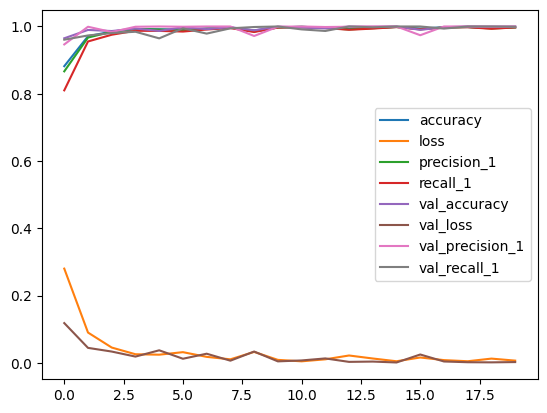

In [ ]:
pd.DataFrame(history.history).plot()
plt.show()

107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 1.0000 - loss: 0.0010 - precision_1: 0.3889 - recall_1: 0.3889
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step
              precision    recall  f1-score   support

          ME       0.62      1.00      0.77      2120
      Others       0.00      0.00      0.00      1274

    accuracy                           0.62      3394
   macro avg       0.31      0.50      0.38      3394
weighted avg       0.39      0.62      0.48      3394



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


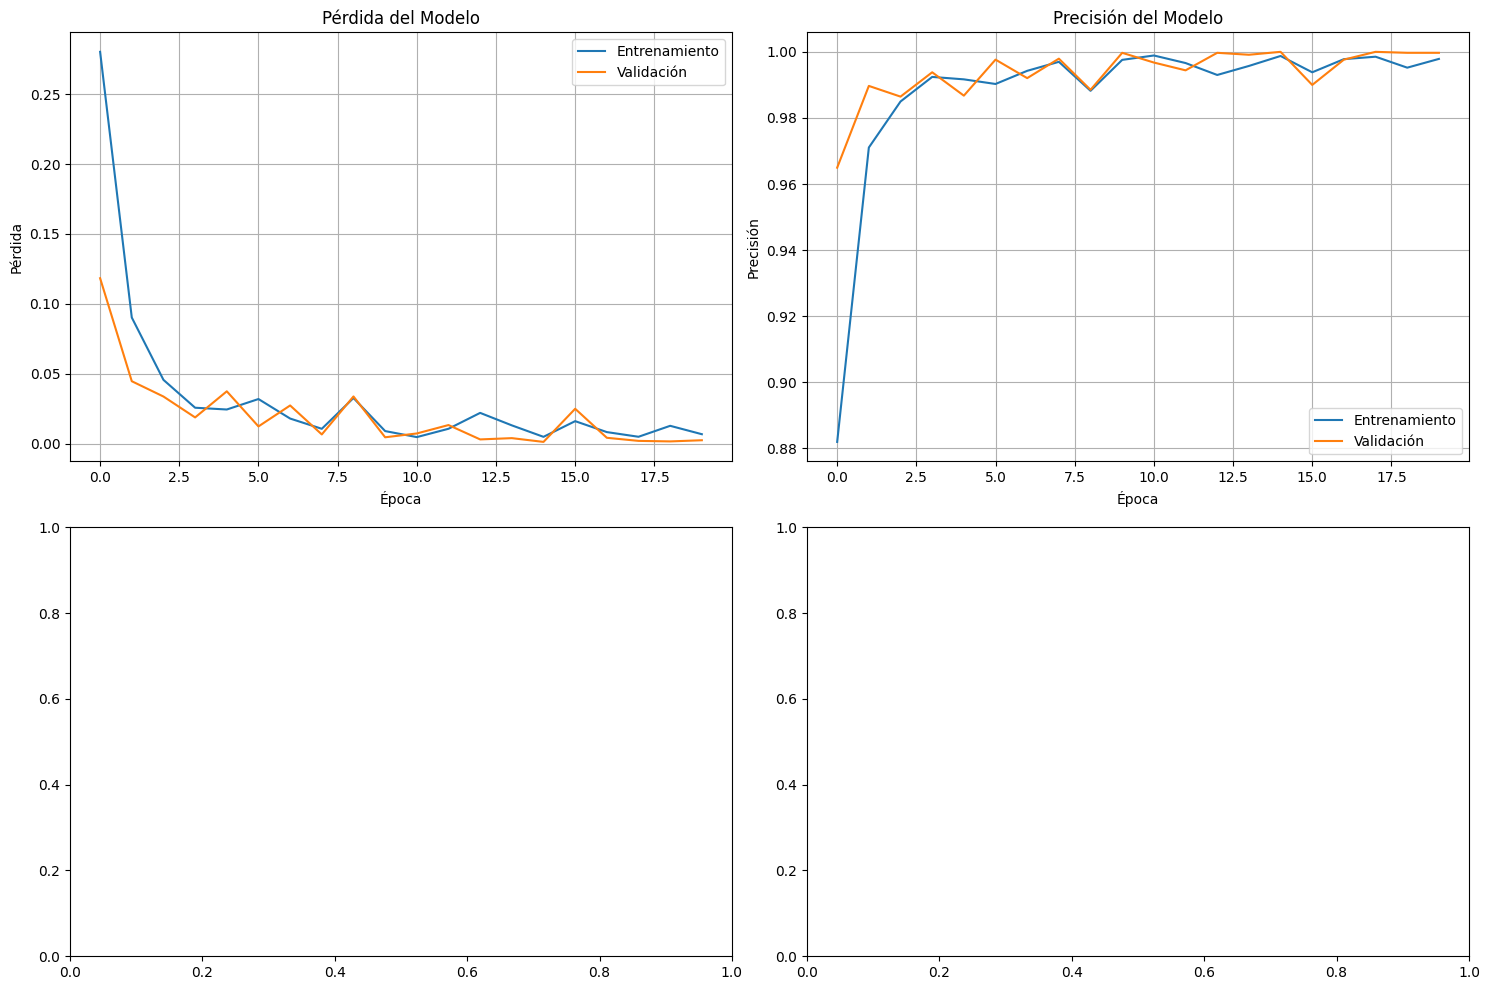

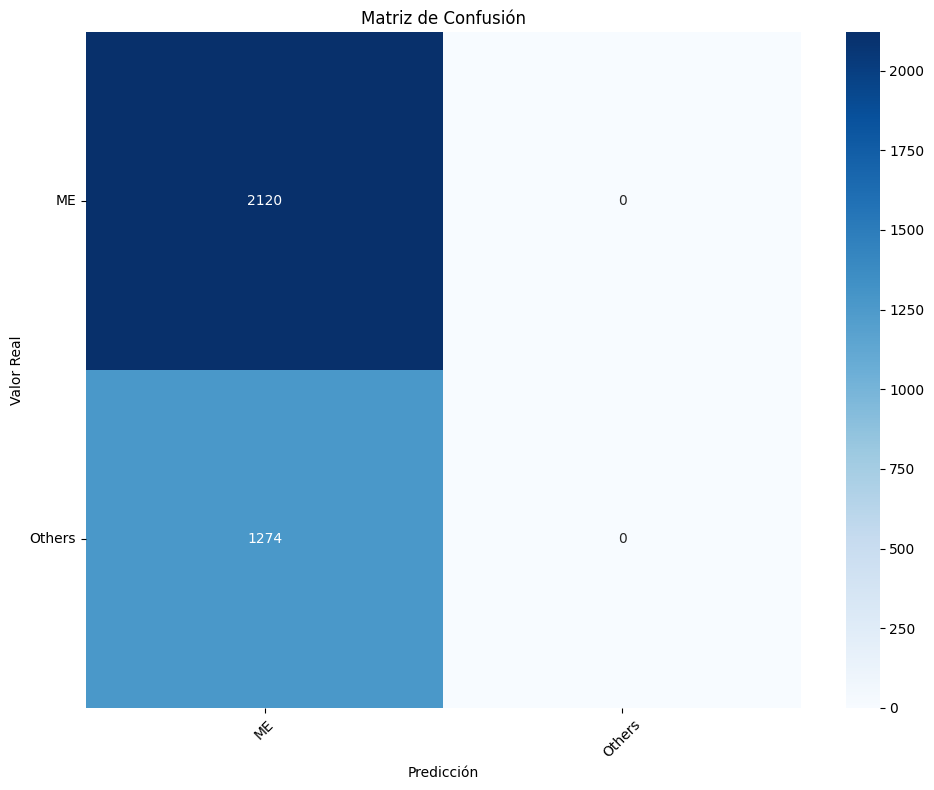

In [ ]:
from sklearn import metrics as ms
import numpy as np
import seaborn as sns

val_loss, val_acc, val_precision, val_recall = model.evaluate(val_generator, verbose=1)

predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print(ms.classification_report(y_true, y_pred, target_names=clases))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(history.history['loss'], label='Entrenamiento')
axes[0, 0].plot(history.history['val_loss'], label='Validación')
axes[0, 0].set_title('Pérdida del Modelo')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 1].plot(history.history['accuracy'], label='Entrenamiento')
axes[0, 1].plot(history.history['val_accuracy'], label='Validación')
axes[0, 1].set_title('Precisión del Modelo')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Precisión')
axes[0, 1].legend()
axes[0, 1].grid(True)
plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

cm = ms.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=clases,
           yticklabels=clases)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Evaluación del modelo

In [1]:
import tensorflow as tf
from sklearn import metrics as ms
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('model_me_ne.h5')

In [7]:
model.evaluate(train_generator, verbose=1)

c:\Users\admin\anaconda3\envs\amb\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6464/6464 ━━━━━━━━━━━━━━━━━━━━ 750s 116ms/step - accuracy: 0.9288 - loss: 0.1710 - precision: 0.9469 - recall: 0.9086


[0.17095817625522614,
 0.9287924766540527,
 0.9468719959259033,
 0.908563494682312]

In [8]:
model.evaluate(val_generator, verbose=1)

808/808 ━━━━━━━━━━━━━━━━━━━━ 90s 112ms/step - accuracy: 0.8864 - loss: 0.2664 - precision: 0.9100 - recall: 0.8576


[0.2664083242416382,
 0.8863776922225952,
 0.9099868535995483,
 0.8575851321220398]

In [9]:
model.evaluate(test_generator, verbose=1)

809/809 ━━━━━━━━━━━━━━━━━━━━ 91s 112ms/step - accuracy: 0.8986 - loss: 0.2453 - precision: 0.9161 - recall: 0.8776


[0.24525563418865204,
 0.8985776305198669,
 0.9160748720169067,
 0.8775510191917419]

## Predicted

In [10]:
ypred_train = model.predict(train_generator)
ypred_val = model.predict(val_generator)
ypred_test = model.predict(test_generator)

6464/6464 ━━━━━━━━━━━━━━━━━━━━ 690s 107ms/step
808/808 ━━━━━━━━━━━━━━━━━━━━ 85s 106ms/step
809/809 ━━━━━━━━━━━━━━━━━━━━ 85s 105ms/step


In [11]:
ypred_train = tf.round(tf.squeeze(ypred_train))
ypred_val = tf.round(tf.squeeze(ypred_val))
ypred_test = tf.round(tf.squeeze(ypred_test))

In [12]:
cfm_train = ms.confusion_matrix(train_generator.classes, ypred_train)
cfm_val = ms.confusion_matrix(val_generator.classes, ypred_val)
cfm_test = ms.confusion_matrix(test_generator.classes, ypred_test)

Text(0.5, 23.52222222222222, 'Predicción')

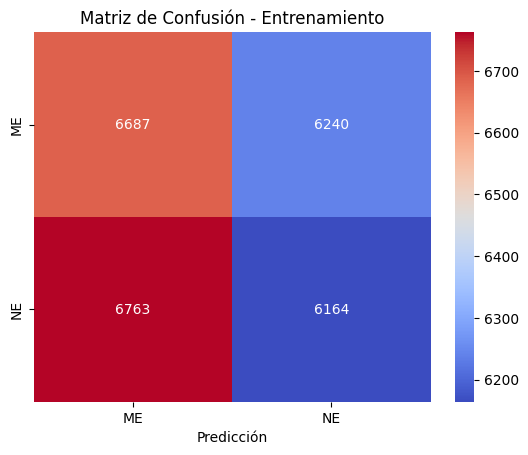

In [13]:
import seaborn as sns
sns.heatmap(cfm_train, annot=True, cmap='coolwarm',
            fmt='n',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.title('Matriz de Confusión - Entrenamiento')
plt.xlabel('Predicción')

Text(0.5, 23.52222222222222, 'Predicción')

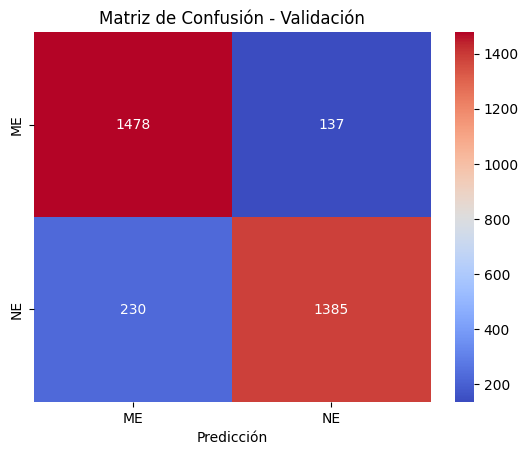

In [14]:
sns.heatmap(cfm_val, annot=True, cmap='coolwarm',
            fmt='n',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción')

Text(0.5, 1.0, 'Matriz de Confusión - Test')

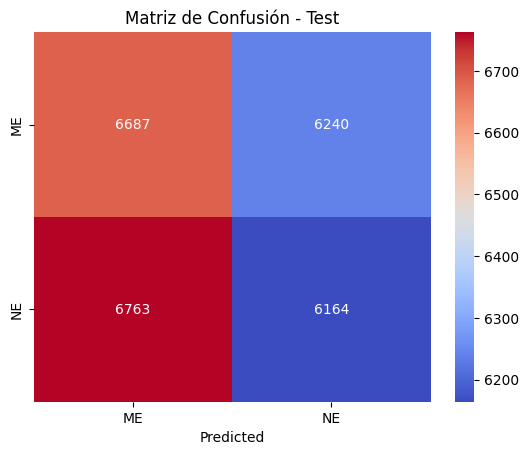

In [15]:
sns.heatmap(cfm_train, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=test_generator.class_indices,
            yticklabels=test_generator.class_indices)
plt.xlabel('Predicted')
plt.title('Matriz de Confusión - Test')